In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Load all datasets

sales = pd.read_csv("sales.csv")
stores = pd.read_csv("stores.csv")
calendar = pd.read_csv("calendar.csv")
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
# Check the shape of each dataset

print("Sales:", sales.shape)
print("Stores:", stores.shape)
print("Calendar:", calendar.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)

Sales: (1000000, 11)
Stores: (100, 5)
Calendar: (731, 6)
Customers: (50000, 5)
Products: (200, 6)


In [4]:
# Display column names of all datasets

print("SALES COLUMNS:")
print(sales.columns.tolist())

print("\nSTORES COLUMNS:")
print(stores.columns.tolist())

print("\nCALENDAR COLUMNS:")
print(calendar.columns.tolist())

print("\nCUSTOMERS COLUMNS:")
print(customers.columns.tolist())

print("\nPRODUCTS COLUMNS:")
print(products.columns.tolist())

SALES COLUMNS:
['order_id', 'order_date', 'product_id', 'store_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit']

STORES COLUMNS:
['store_id', 'store_name', 'city', 'country', 'store_type']

CALENDAR COLUMNS:
['date', 'year', 'month', 'day', 'week', 'day_of_week']

CUSTOMERS COLUMNS:
['customer_id', 'age', 'gender', 'loyalty_member', 'join_date']

PRODUCTS COLUMNS:
['product_id', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g']


In [5]:
# Merge sales with customer information
df = sales.merge(customers, on="customer_id", how="left")

# Merge with product information
df = df.merge(products, on="product_id", how="left")

# Merge with store information
df = df.merge(stores, on="store_id", how="left")

# Merge with calendar information
df = df.merge(calendar, left_on="order_date", right_on="date", how="left")

# Display the shape of the final dataset
print("Final dataset shape:", df.shape)

# Display the first 5 rows
df.head()

Final dataset shape: (1000000, 30)


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,store_name,city,country,store_type,date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,Chocolate Store 93,Sydney,UK,Airport,2023-01-07,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,Chocolate Store 65,New York,Australia,Retail,2023-10-22,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,Chocolate Store 78,London,UK,Airport,2023-05-07,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,Chocolate Store 88,Toronto,USA,Retail,2024-06-23,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,Chocolate Store 54,London,Canada,Online,2024-09-24,2024,9,24,39,1


In [6]:
# Initial inspection of the combined dataset

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (1000000, 30)

Data Types:
order_id           object
order_date         object
product_id         object
store_id           object
customer_id        object
quantity            int64
unit_price        float64
discount          float64
revenue           float64
cost              float64
profit            float64
age                 int64
gender             object
loyalty_member      int64
join_date          object
product_name       object
brand              object
category           object
cocoa_percent     float64
weight_g          float64
store_name         object
city               object
country            object
store_type         object
date               object
year                int64
month               int64
day                 int64
week                int64
day_of_week         int64
dtype: object

Missing Values:
order_id             0
order_date           0
product_id           0
store_id             0
customer_id          0
quantity             0
unit_pric

In [7]:
# Descriptive statistics for numerical columns

df.describe()

,quantity,unit_price,discount,revenue,cost,profit,age,loyalty_member,cocoa_percent,weight_g,year,month,day,week,day_of_week
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,990236.000000,990236.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565,44.044222,0.501898,69.148132,107.431400,2023.50043,6.516521,15.726768,26.444866,2.999049
std,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760,15.330664,0.499997,14.597137,50.719617,0.50000,3.449879,8.806623,15.069053,2.003559
min,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000,18.000000,0.000000,50.000000,50.000000,2023.00000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000,31.000000,0.000000,50.000000,80.000000,2023.00000,4.000000,8.000000,13.000000,1.000000
50%,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000,44.000000,1.000000,70.000000,100.000000,2024.00000,7.000000,16.000000,26.000000,3.000000
75%,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000,57.000000,1.000000,80.000000,120.000000,2024.00000,10.000000,23.000000,39.000000,5.000000
max,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000,70.000000,1.000000,90.000000,200.000000,2024.00000,12.000000,31.000000,52.000000,6.000000


In [8]:
# Summary of important sales variables

df[[
    "quantity",
    "unit_price",
    "discount",
    "revenue",
    "cost",
    "profit",
    "age"
]].describe()

,quantity,unit_price,discount,revenue,cost,profit,age
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565,44.044222
std,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760,15.330664
min,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000,18.000000
25%,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000,31.000000
50%,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000,44.000000
75%,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000,57.000000
max,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000,70.000000


In [9]:
# Convert order_date to datetime format
df["order_date"] = pd.to_datetime(df["order_date"])

In [10]:
# Calculate monthly revenue
monthly_sales = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

monthly_sales.head()

,revenue
order_date,
2023-01,1095019.20
2023-02,968948.95
2023-03,1084656.09
2023-04,1038425.32
2023-05,1083418.79


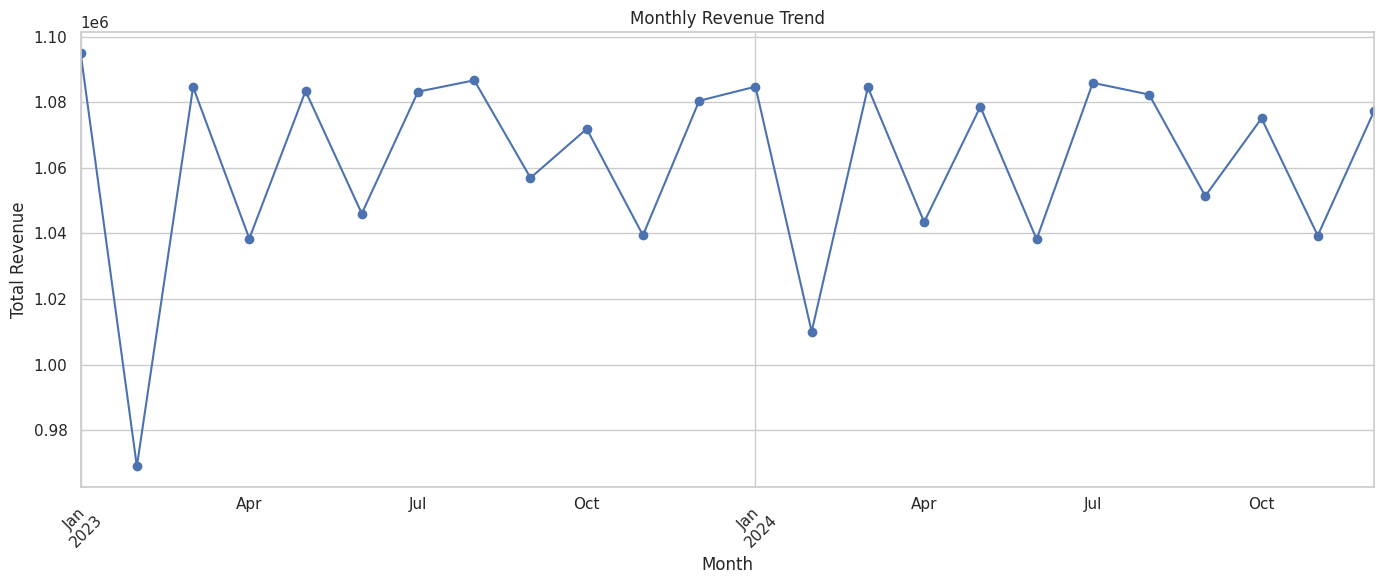

In [11]:
# Plot monthly sales trend

plt.figure(figsize=(14, 6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Calculate quarterly revenue

quarterly_sales = df.groupby(
    df["order_date"].dt.to_period("Q")
)["revenue"].sum()

quarterly_sales


,revenue
order_date,
2023Q1,3148624.24
2023Q2,3167889.13
2023Q3,3226848.82
2023Q4,3191744.08
2024Q1,3179354.04
2024Q2,3160310.56
2024Q3,3219690.97
2024Q4,3191667.02


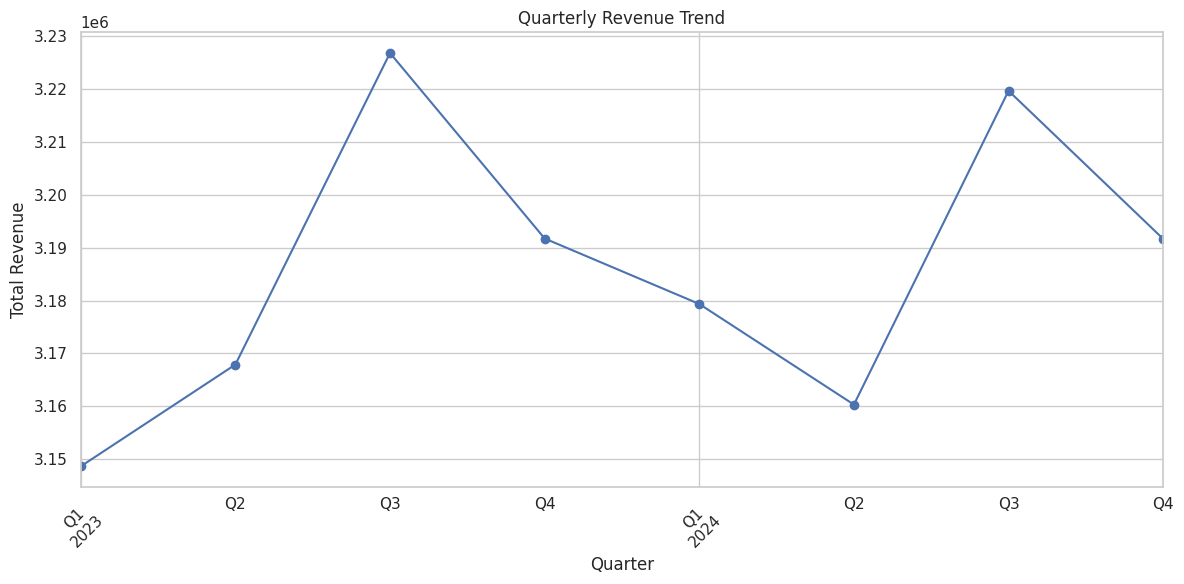

In [13]:
# Plot quarterly sales trend

plt.figure(figsize=(12, 6))

quarterly_sales.plot(kind="line", marker="o")

plt.title("Quarterly Revenue Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Check minimum and maximum customer age

print("Minimum Age:", df["age"].min())
print("Maximum Age:", df["age"].max())

Minimum Age: 18
Maximum Age: 70


In [15]:
# Create customer age groups

bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = [
    "Under 18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=False
)

df["age_group"].value_counts().sort_index()

,count
age_group,
Under 18,0
18-24,133960
25-34,184663
35-44,188556
45-54,188728
55-64,190541
65+,113552


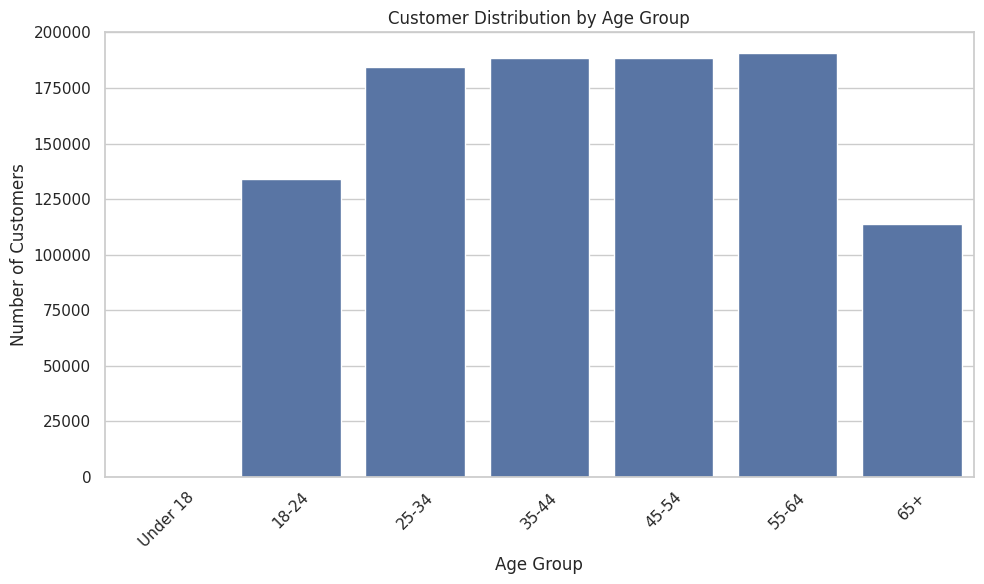

In [16]:
# Customer age group distribution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="age_group",
    order=labels
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Count customers by gender
gender_counts = df["gender"].value_counts()

print(gender_counts)

gender
Male      504311
Female    495689
Name: count, dtype: int64


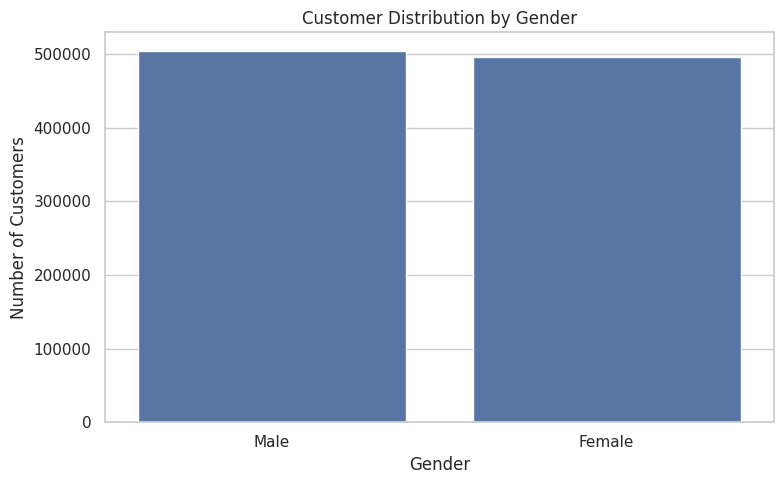

In [18]:
# Gender distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

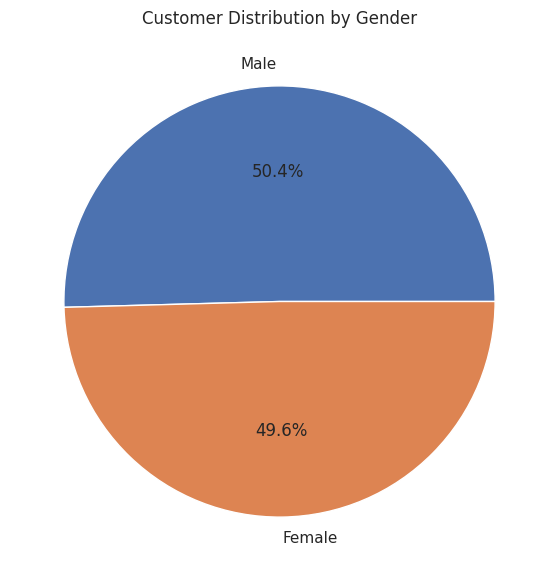

In [19]:
# Gender distribution pie chart

gender_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7, 7)
)

plt.title("Customer Distribution by Gender")
plt.ylabel("")
plt.show()

In [20]:
# Top 10 best-selling products

top_products = (
    df.groupby("product_name")["quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

product_name
Dark Chocolate 50%       208996
Truffle Chocolate 80%    193431
Praline Chocolate 50%    162670
Milk Chocolate 70%       162335
Dark Chocolate 60%       149346
White Chocolate 50%      149170
White Chocolate 90%      134217
Truffle Chocolate 90%    133692
White Chocolate 80%      133171
Praline Chocolate 70%    132564
Name: quantity, dtype: int64


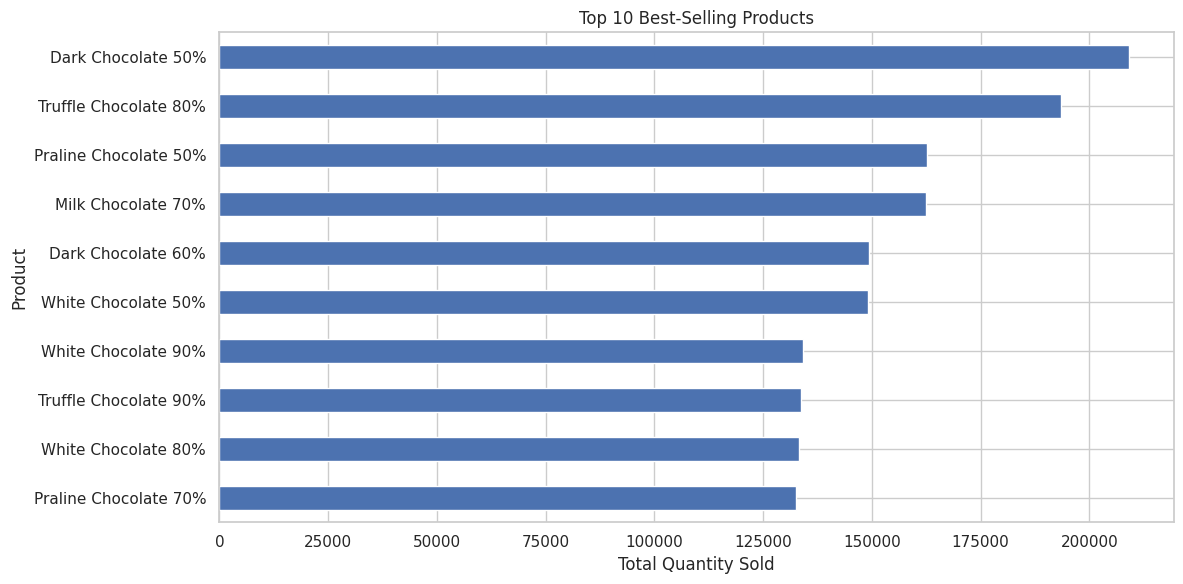

In [21]:
# Visualise top 10 best-selling products

plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [22]:
# Calculate total revenue by product category

category_revenue = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(category_revenue)

category
Praline    6665641.32
White      6070172.20
Dark       5298123.27
Truffle    3924343.24
Milk       3280368.19
Name: revenue, dtype: float64


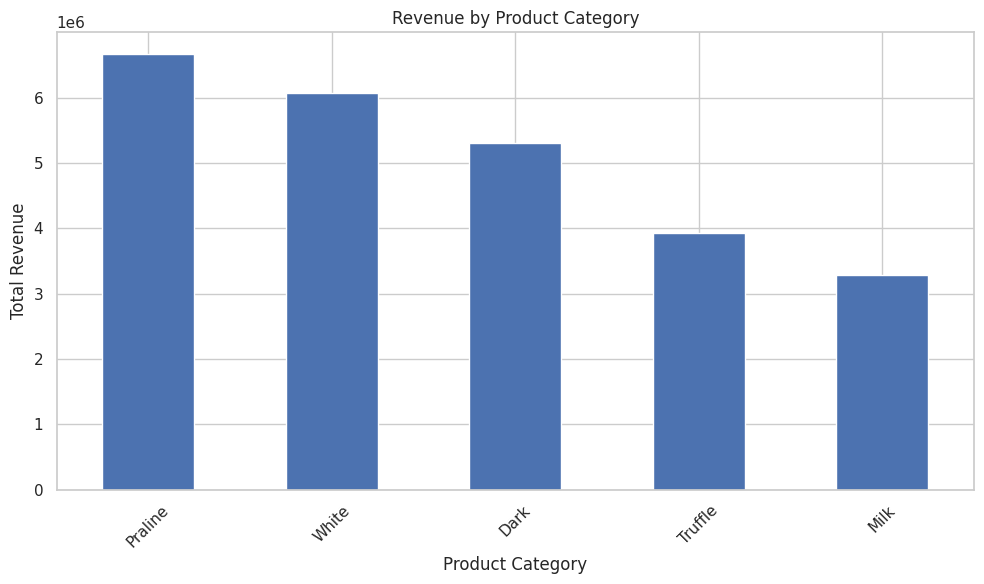

In [23]:
# Revenue by product category

plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Select important numerical columns

numeric_cols = [
    "age",
    "quantity",
    "unit_price",
    "discount",
    "revenue",
    "cost",
    "profit"
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,age,quantity,unit_price,discount,revenue,cost,profit
age,1.000000,-0.000076,-0.000999,-0.000108,-0.000370,-0.000448,-0.000237
quantity,-0.000076,1.000000,0.000137,-0.000147,0.733962,0.722677,0.709027
unit_price,-0.000999,0.000137,1.000000,-0.000639,0.599279,0.590022,0.578986
discount,-0.000108,-0.000147,-0.000639,1.000000,-0.127252,-0.125071,-0.123258
revenue,-0.000370,0.733962,0.599279,-0.127252,1.000000,0.984520,0.966183
cost,-0.000448,0.722677,0.590022,-0.125071,0.984520,1.000000,0.906032
profit,-0.000237,0.709027,0.578986,-0.123258,0.966183,0.906032,1.000000


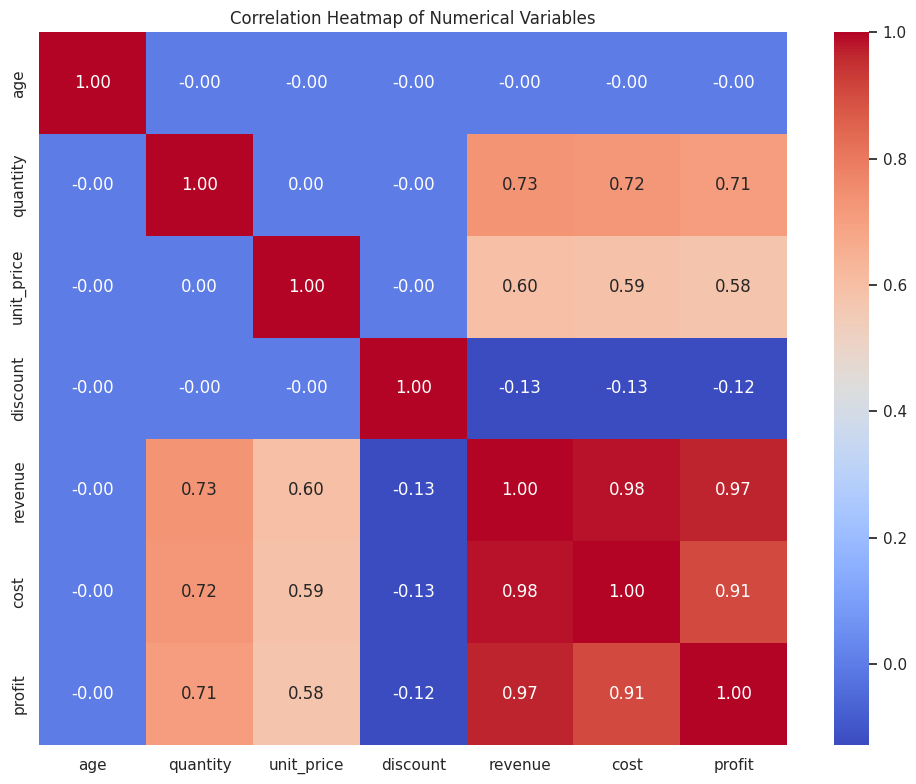

In [25]:
# Correlation heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

In [26]:
# Generate key business insights

print("Total Revenue:", df["revenue"].sum())
print("Total Profit:", df["profit"].sum())

print("\nTop 10 Best-Selling Products:")
print(top_products)

print("\nRevenue by Category:")
print(category_revenue)

print("\nCustomer Age Groups:")
print(df["age_group"].value_counts().sort_index())

print("\nGender Distribution:")
print(gender_counts)

Total Revenue: 25486128.859999992
Total Profit: 10194564.629999997

Top 10 Best-Selling Products:
product_name
Dark Chocolate 50%       208996
Truffle Chocolate 80%    193431
Praline Chocolate 50%    162670
Milk Chocolate 70%       162335
Dark Chocolate 60%       149346
White Chocolate 50%      149170
White Chocolate 90%      134217
Truffle Chocolate 90%    133692
White Chocolate 80%      133171
Praline Chocolate 70%    132564
Name: quantity, dtype: int64

Revenue by Category:
category
Praline    6665641.32
White      6070172.20
Dark       5298123.27
Truffle    3924343.24
Milk       3280368.19
Name: revenue, dtype: float64

Customer Age Groups:
age_group
Under 18         0
18-24       133960
25-34       184663
35-44       188556
45-54       188728
55-64       190541
65+         113552
Name: count, dtype: int64

Gender Distribution:
gender
Male      504311
Female    495689
Name: count, dtype: int64


## Key Insights

1. The dataset generated a total revenue of approximately 25.49 million and total profit of approximately 10.19 million.

2. Dark Chocolate 50% was the best-selling product, with 208,996 units sold, followed by Truffle Chocolate 80% with 193,431 units.

3. Praline was the highest revenue-generating category, generating approximately 6.67 million in revenue. White was the second-highest category with approximately 6.07 million.

4. The 55-64 age group had the highest number of customers, with 190,541 customers, followed by the 45-54 age group with 188,728 customers.

5. The customer base was almost evenly distributed by gender, with 504,311 male customers and 495,689 female customers.

6. There were no customers in the Under 18 age group based on the dataset.

## Business Recommendations

- Focus on promoting the best-selling products, especially Dark Chocolate 50% and Truffle Chocolate 80%, to maintain strong sales performance.

- Praline and White categories generate the highest revenue, so the business should prioritise their availability, marketing, and product development.

- Marketing campaigns can focus strongly on customers aged 35-64, as these age groups represent the largest customer segments.

- Since the customer base is nearly evenly divided between male and female customers, marketing campaigns should target both genders rather than focusing heavily on one group.

- The business can use the monthly and quarterly sales trends to identify high-performing periods and plan inventory and promotional campaigns accordingly.